# Dark UX Patterns Analysis
This notebook explores the dataset of dark UX patterns in websites generated by AI website builder - Lovable and Figma Make.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import textwrap

# 1. Nord Minimalist Categorical Palette (Best for Bar Charts)
THESIS_CATEGORICAL_PALETTE = ['#5E81AC', '#88C0D0', '#A3BE8C', '#EBCB8B', '#D08770', '#BF616A']

# 2. Flare Sequential Colormap (Best for Heatmaps)
THESIS_SEQUENTIAL_CMAP = 'flare'

# --- Global Application ---

# Apply the Nord palette to all future Seaborn plots
sns.set_palette(sns.color_palette(THESIS_CATEGORICAL_PALETTE))

# Set general plot aesthetics for a clean, academic look
plt.rcParams.update({
    'axes.facecolor': 'white',
    'axes.edgecolor': '#4C566A', # Nord dark gray for borders
    'axes.labelcolor': '#2E3440', # Nord polar night for text
    'xtick.color': '#4C566A',
    'ytick.color': '#4C566A',
    'text.color': '#2E3440',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif'
})

# Load data
df = pd.read_csv('dark_ux_patterns.csv')
df.head()

,Index,Link,Platform,Incentive,High-level category,Dark UX Pattern,Secondary possibility,Description,Count,Location
0,1.0,https://goods-bloom-flow.lovable.app/,Lovable,Baseline,Sneaking,(De)contextualizing Cues,Scarcity or popularity claims,"""BESTSELLER"" and ""POPULAR"" badges on products ...",2,"Product page,Shop-All page"
1,NaN,https://goods-bloom-flow.lovable.app/,Lovable,Baseline,Obstruction,Dead Ends,Bait and switch,"Button ""Our Story"" leads to Shop-All page.",1,Home page
2,NaN,https://goods-bloom-flow.lovable.app/,Lovable,Baseline,Obstruction,Dead Ends,NaN,Inactive links in footer.,7,Footer
3,NaN,https://goods-bloom-flow.lovable.app/,Lovable,Baseline,Sneaking,Conflicting Information,NaN,Product description does not match the product...,3,"Product page,Shop-All page"
4,NaN,https://goods-bloom-flow.lovable.app/,Lovable,Baseline,Obstruction,Price Comparison Prevention,NaN,Product description claims details that are no...,2,Product page


## Data Preparation
We aggregate the data by website (Link) to analyze the total quantity of patterns per site.

In [ ]:
site_data = df.groupby(['Link', 'Platform', 'Incentive']).agg(
    instance_count=('Dark UX Pattern', 'count'),
    element_count=('Count', 'sum')
).reset_index()

site_data.head()

,Link,Platform,Incentive,instance_count,element_count
0,https://cart-and-crave.lovable.app,Lovable,Business,11,28
1,https://charm-store-journey.lovable.app,Lovable,Baseline,4,18
2,https://clear-cart-co.lovable.app,Lovable,User,8,26
3,https://clear-flow-commerce.lovable.app,Lovable,User,8,27
4,https://curated-joy-shop.lovable.app,Lovable,Baseline,7,19


## RQ1: To what extent do websites produced by AI-powered website builders contain dark UX patterns?

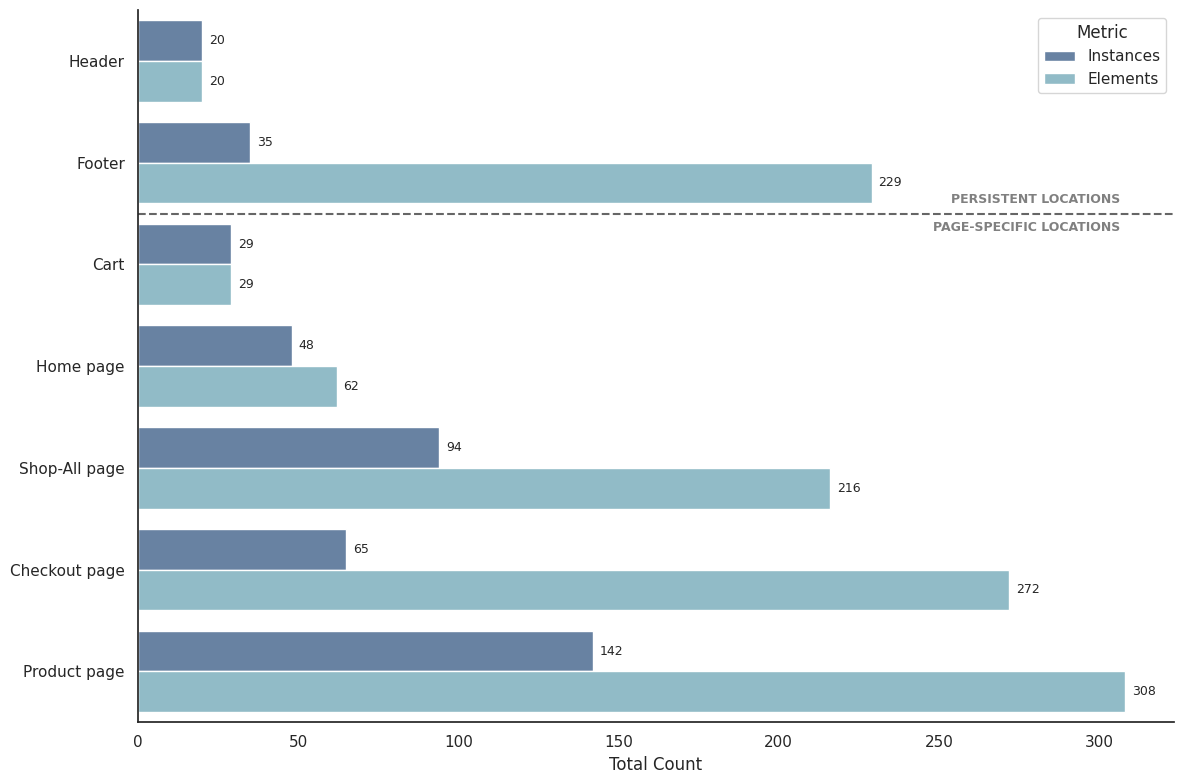

In [ ]:
df_loc = df.copy()
df_loc['Location'] = df_loc['Location'].str.split(',')
df_loc = df_loc.explode('Location')
df_loc['Location'] = df_loc['Location'].str.strip()

permanent_locs = ['Header', 'Footer']
location_stats = df_loc.groupby('Location').agg(
    Instances=('Dark UX Pattern', 'count'),
    Elements=('Count', 'sum')
).reset_index()

location_stats['Type'] = location_stats['Location'].apply(
    lambda x: 'Permanent' if x in permanent_locs else 'Page-Specific'
)

perm = location_stats[location_stats['Type'] == 'Permanent'].sort_values('Elements', ascending=True)
page_spec = location_stats[location_stats['Type'] == 'Page-Specific'].sort_values('Elements', ascending=True)

location_stats_final = pd.concat([perm, page_spec]).reset_index(drop=True)
plot_df = location_stats_final.melt(id_vars=['Location', 'Type'], var_name='Metric', value_name='Total')

plt.figure(figsize=(12, 8), facecolor='white')
sns.set_theme(style="white")
ax = sns.barplot(data=plot_df, y='Location', x='Total', hue='Metric', palette=THESIS_CATEGORICAL_PALETTE)

num_perm = len(location_stats[location_stats['Type'] == 'Permanent'])

if 0 < num_perm < len(location_stats):
    ax.axhline(y=num_perm - 0.5, color='black', linestyle='--', linewidth=1.5, alpha=0.6)

    max_x = plot_df['Total'].max()
    ax.text(max_x, num_perm - 0.7, 'PERSISTENT LOCATIONS ',
            ha='right', va='top', fontsize=9, fontweight='bold', color='gray')
    ax.text(max_x, num_perm - 0.3, 'PAGE-SPECIFIC LOCATIONS ',
            ha='right', va='bottom', fontsize=9, fontweight='bold', color='gray')

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{int(width)}',
                    (p.get_x() + width, p.get_y() + p.get_height() / 2),
                    ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)

ax.set_xlabel('Total Count', fontsize=12)
ax.set_ylabel('')
sns.despine()
plt.tight_layout()
plt.show()

## RQ2: Which categories of dark UX patterns are most frequently present in AI-generated website designs?

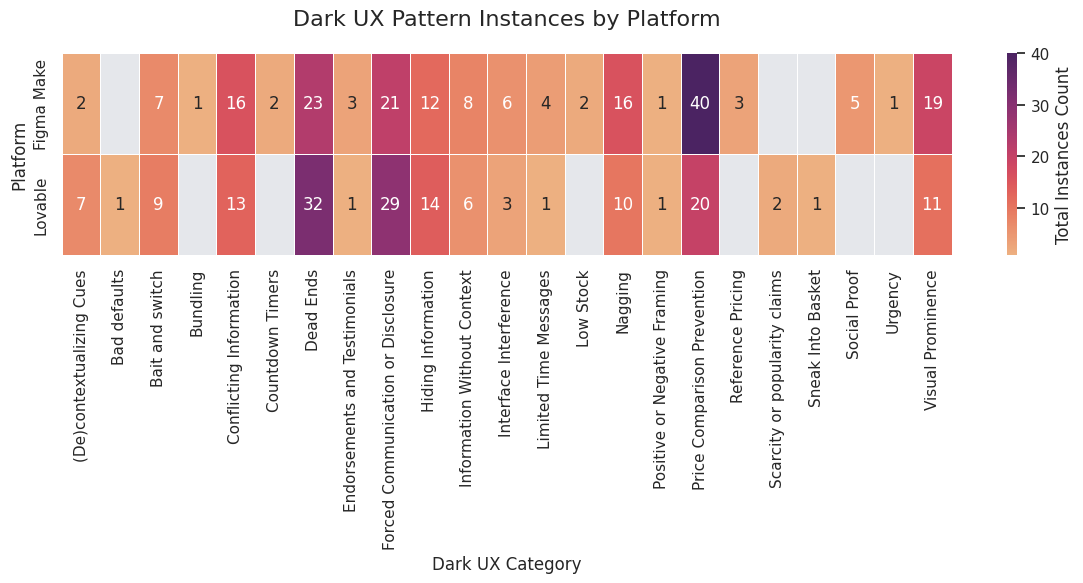

In [ ]:
platform_pivot = df.groupby(['Platform', 'Dark UX Pattern']).size().unstack(fill_value=0)

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(12, 6))

mask = (platform_pivot == 0)
ax.set_facecolor('#e5e7eb')

sns.heatmap(platform_pivot,
            annot=True,
            fmt='d',
            mask=mask,
            cmap=THESIS_SEQUENTIAL_CMAP,
            linewidths=.5,
            cbar_kws={'label': 'Total Instances Count'},
            ax=ax)

ax.set_title('Dark UX Pattern Instances by Platform', fontsize=16, pad=20)
ax.set_xlabel('Dark UX Category', fontsize=12)
ax.set_ylabel('Platform', fontsize=12)

plt.tight_layout()
plt.show()

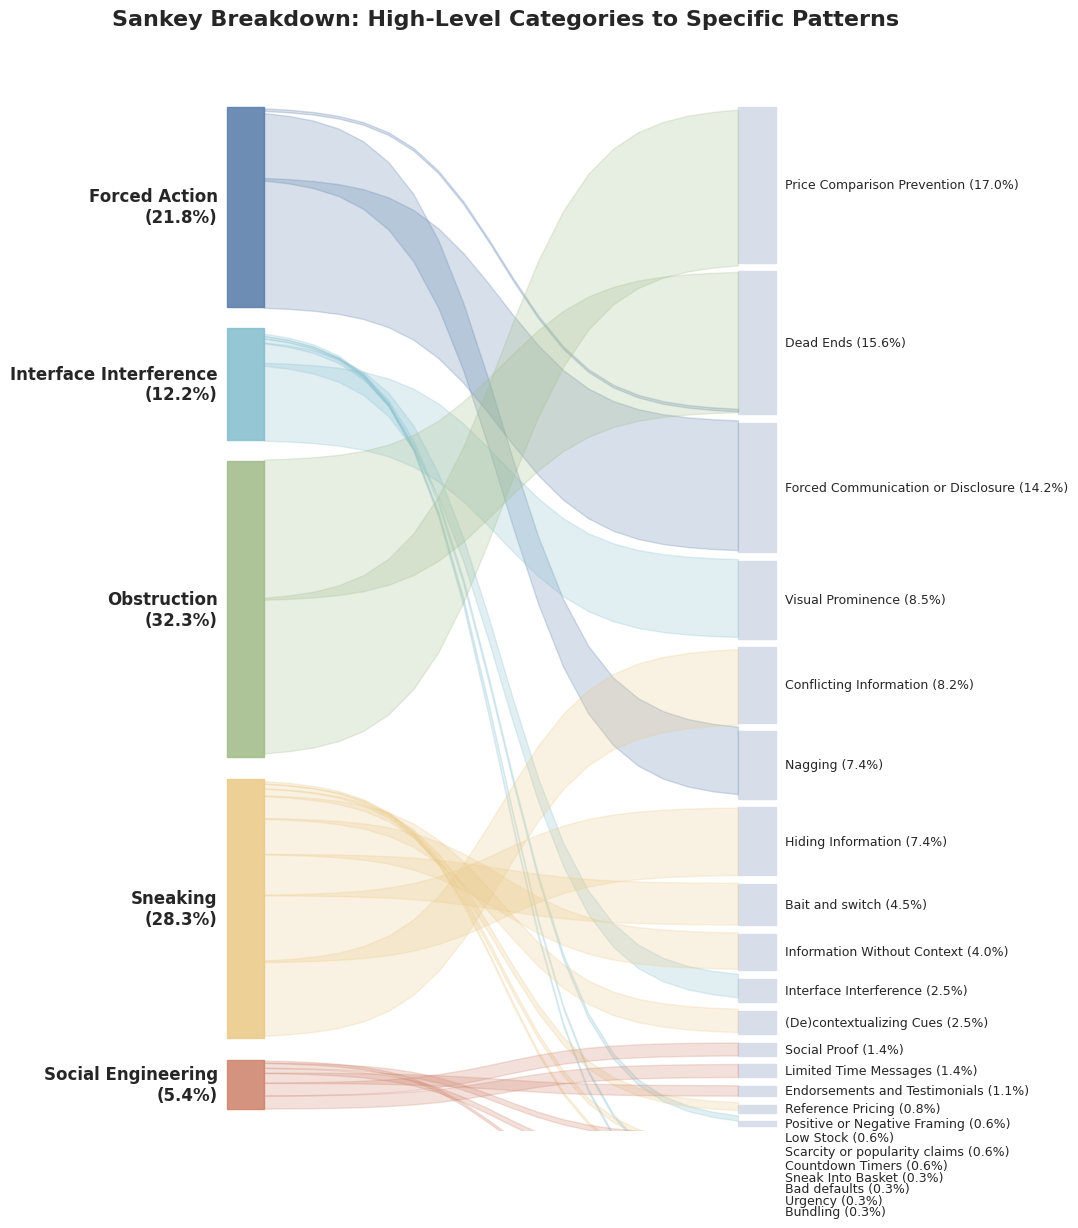

In [ ]:
counts = df.groupby(['High-level category', 'Dark UX Pattern']).size().reset_index(name='value')
total_instances = counts['value'].sum()
counts = counts.sort_values(['High-level category', 'value'], ascending=[True, False])

# 2. Setup Plot
fig, ax = plt.subplots(figsize=(12, 14), facecolor='white')
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis('off')

# Nord Palette & Mapping
NORD_PALETTE = ['#5E81AC', '#88C0D0', '#A3BE8C', '#EBCB8B', '#D08770', '#BF616A']
categories = sorted(counts['High-level category'].unique())
cat_colors = {cat: NORD_PALETTE[i % len(NORD_PALETTE)] for i, cat in enumerate(categories)}

# 3. Drawing Logic
left_x, right_x, node_width = 20, 75, 4
y_offset_left, y_offset_right = 95, 95
cat_nodes, pat_nodes = {}, {}

# Draw Left Nodes (Categories)
for cat in categories:
    h = (df[df['High-level category'] == cat].shape[0] / total_instances) * 85
    y_start = y_offset_left - h
    ax.add_patch(patches.Rectangle((left_x, y_start), node_width, h, color=cat_colors[cat], alpha=0.9))
    ax.text(left_x - 1, y_start + h/2, f"{cat}\n({(h/85*100):.1f}%)", ha='right', va='center', fontweight='bold')
    cat_nodes[cat] = {'current_y': y_start}
    y_offset_left -= (h + 2)

# Draw Right Nodes (Patterns)
patterns = df['Dark UX Pattern'].value_counts().index.tolist()
for pat in patterns:
    h = (df[df['Dark UX Pattern'] == pat].shape[0] / total_instances) * 85
    y_start = y_offset_right - h
    ax.add_patch(patches.Rectangle((right_x, y_start), node_width, h, color='#D8DEE9'))
    ax.text(right_x + node_width + 1, y_start + h/2, f"{pat} ({(h/85*100):.1f}%)", ha='left', va='center', fontsize=9)
    pat_nodes[pat] = {'current_y': y_start}
    y_offset_right -= (h + 0.8)

# 4. Draw Ribbons
for _, row in counts.iterrows():
    flow_h = (row['value'] / total_instances) * 85
    y_l, y_r = cat_nodes[row['High-level category']]['current_y'], pat_nodes[row['Dark UX Pattern']]['current_y']

    # Simple sigmoid curve for the ribbon
    x_curve = np.linspace(left_x + node_width, right_x, 20)
    s = 1 / (1 + np.exp(-10 * (np.linspace(0, 1, 20) - 0.5)))
    y_top = y_l + flow_h + (y_r - y_l) * s
    y_bot = y_l + (y_r - y_l) * s
    ax.fill(np.concatenate([x_curve, x_curve[::-1]]), np.concatenate([y_top, y_bot[::-1]]),
            color=cat_colors[row['High-level category']], alpha=0.25)

    cat_nodes[row['High-level category']]['current_y'] += flow_h
    pat_nodes[row['Dark UX Pattern']]['current_y'] += flow_h

plt.title("Sankey Breakdown: High-Level Categories to Specific Patterns", fontsize=16, pad=20, fontweight='bold')
plt.show()

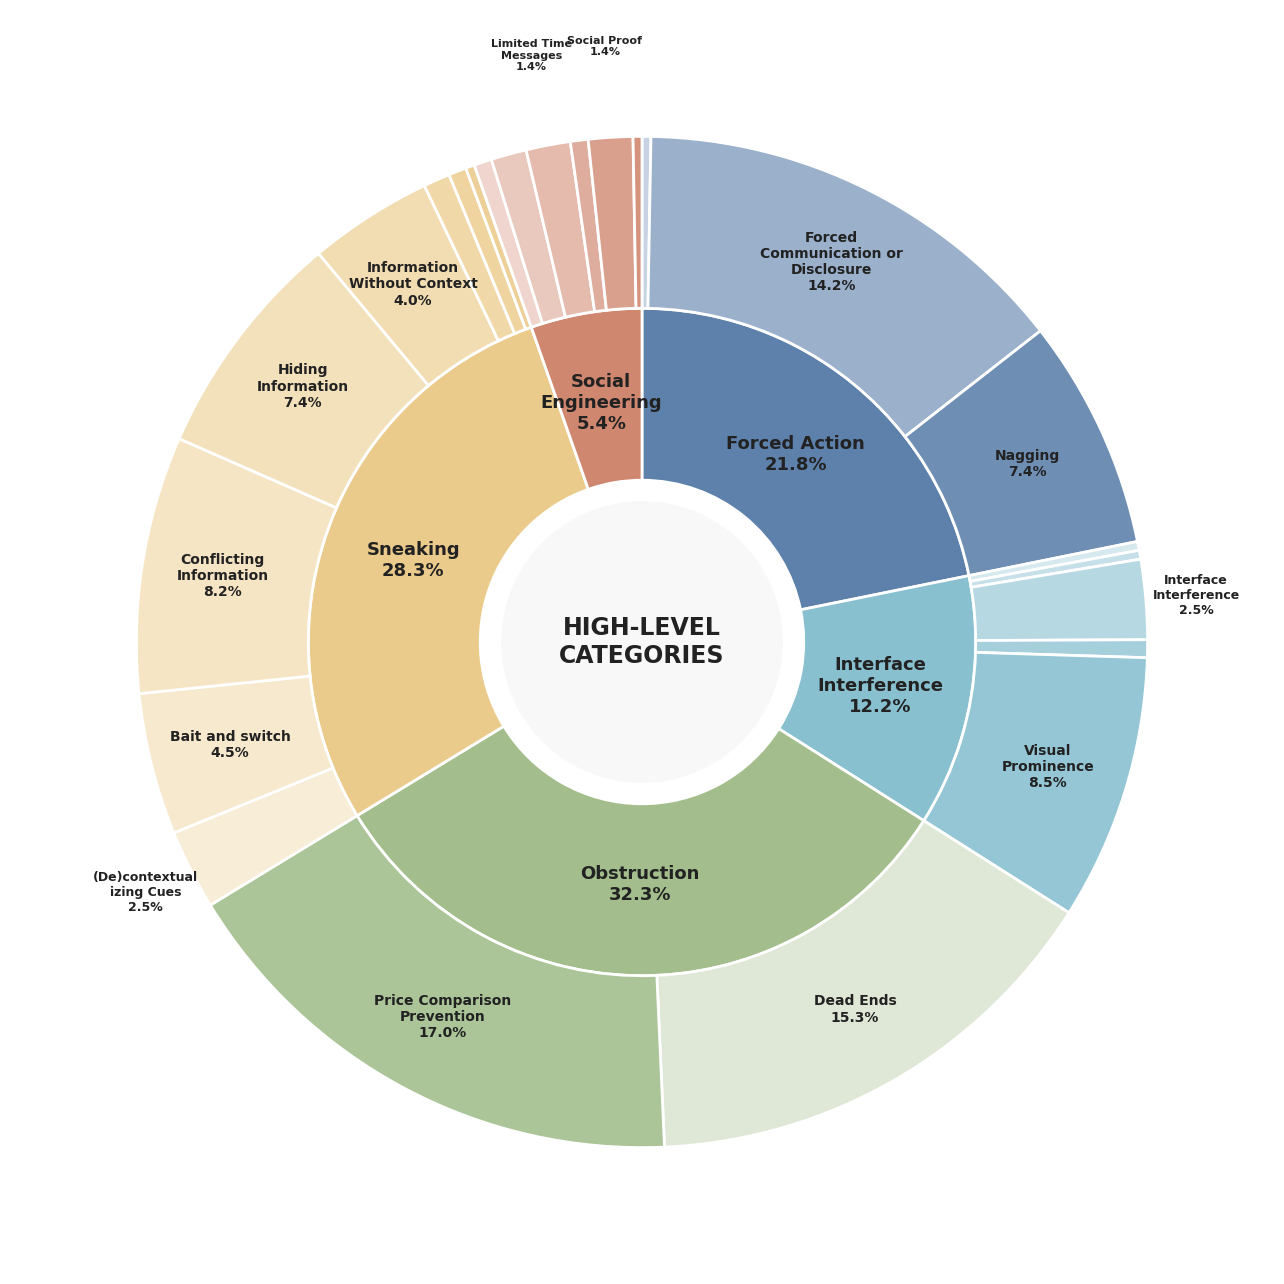

In [ ]:
# =========================
# 1. DATA AGGREGATION
# =========================
inner_counts = df.groupby('High-level category').size()
outer_counts = df.groupby(
    ['High-level category', 'Dark UX Pattern']
).size()

# Percentages
inner_total = inner_counts.sum()
outer_total = outer_counts.sum()

inner_pct = inner_counts / inner_total * 100
outer_pct = outer_counts / outer_total * 100

# =========================
# 2. COLOR HELPERS
# =========================
def generate_shades(hex_color, n):

    base = np.array(mcolors.to_rgb(hex_color))
    shades = []

    for i in range(n):
        factor = 0.35 + (i / max(n - 1, 1)) * 0.55
        blended = base * factor + (1 - factor)
        shades.append(blended)

    return shades


inner_colors = [
    THESIS_CATEGORICAL_PALETTE[i % len(THESIS_CATEGORICAL_PALETTE)]
    for i in range(len(inner_counts))
]

outer_colors = []

for i, (cat, _) in enumerate(inner_counts.items()):

    base_color = inner_colors[i]
    sub_patterns = outer_counts[cat]

    outer_colors.extend(
        generate_shades(base_color, len(sub_patterns))
    )

# =========================
# 3. FIGURE
# =========================
fig, ax = plt.subplots(
    figsize=(13, 13),
    facecolor="white"
)

ax.set_facecolor("white")

# =========================
# 4. DRAW RINGS
# =========================
inner_width = 0.34
outer_width = 0.34

inner_wedges, _ = ax.pie(
    inner_counts.values,
    radius=0.66,
    colors=inner_colors,
    startangle=90,
    counterclock=False,
    wedgeprops=dict(
        width=inner_width,
        edgecolor="white",
        linewidth=2
    )
)

outer_wedges, _ = ax.pie(
    outer_counts.values,
    radius=1,
    colors=outer_colors,
    startangle=90,
    counterclock=False,
    wedgeprops=dict(
        width=outer_width,
        edgecolor="white",
        linewidth=2
    )
)

# =========================
# 5. INNER LABELS + %
# =========================
for wedge, label, pct in zip(
    inner_wedges,
    inner_counts.index,
    inner_pct.values
):

    angle = (wedge.theta2 + wedge.theta1) / 2
    r = 0.48

    x = np.cos(np.deg2rad(angle)) * r
    y = np.sin(np.deg2rad(angle)) * r

    wrapped = "\n".join(textwrap.wrap(label, width=14))

    ax.text(
        x,
        y,
        f"{wrapped}\n{pct:.1f}%",
        ha='center',
        va='center',
        fontsize=13,
        fontweight='bold',
        color="#222222"
    )

# =========================
# 6. OUTER LABELS + %
# =========================
outer_labels = outer_counts.index.get_level_values(1)
outer_pct_vals = outer_pct.values

for wedge, label, pct in zip(
    outer_wedges,
    outer_labels,
    outer_pct_vals
):

    angle = (wedge.theta2 + wedge.theta1) / 2
    angular_size = wedge.theta2 - wedge.theta1

    if angular_size > 14:
        r = 0.84
        fontsize = 10
        wrap_width = 16

    elif angular_size > 8:
        r = 1.10
        fontsize = 9
        wrap_width = 14

    elif angular_size > 5:
        r = 1.18
        fontsize = 8
        wrap_width = 12

    else:
        continue

    x = np.cos(np.deg2rad(angle)) * r
    y = np.sin(np.deg2rad(angle)) * r

    wrapped = "\n".join(textwrap.wrap(label, width=wrap_width))

    ax.text(
        x,
        y,
        f"{wrapped}\n{pct:.1f}%",
        ha='center',
        va='center',
        fontsize=fontsize,
        fontweight='semibold',
        color="#222222"
    )

# =========================
# 7. CENTER CIRCLE
# =========================
centre_circle = plt.Circle(
    (0, 0),
    0.28,
    fc="#F8F8F8"
)

ax.add_artist(centre_circle)

ax.text(
    0,
    0,
    "HIGH-LEVEL\nCATEGORIES",
    ha='center',
    va='center',
    fontsize=17,
    fontweight='bold',
    color="#222222"
)

ax.set(aspect="equal")
plt.tight_layout()
plt.show()

## RQ3: How can the occurrence of dark UX patterns in AI-generated websites be mitigated?

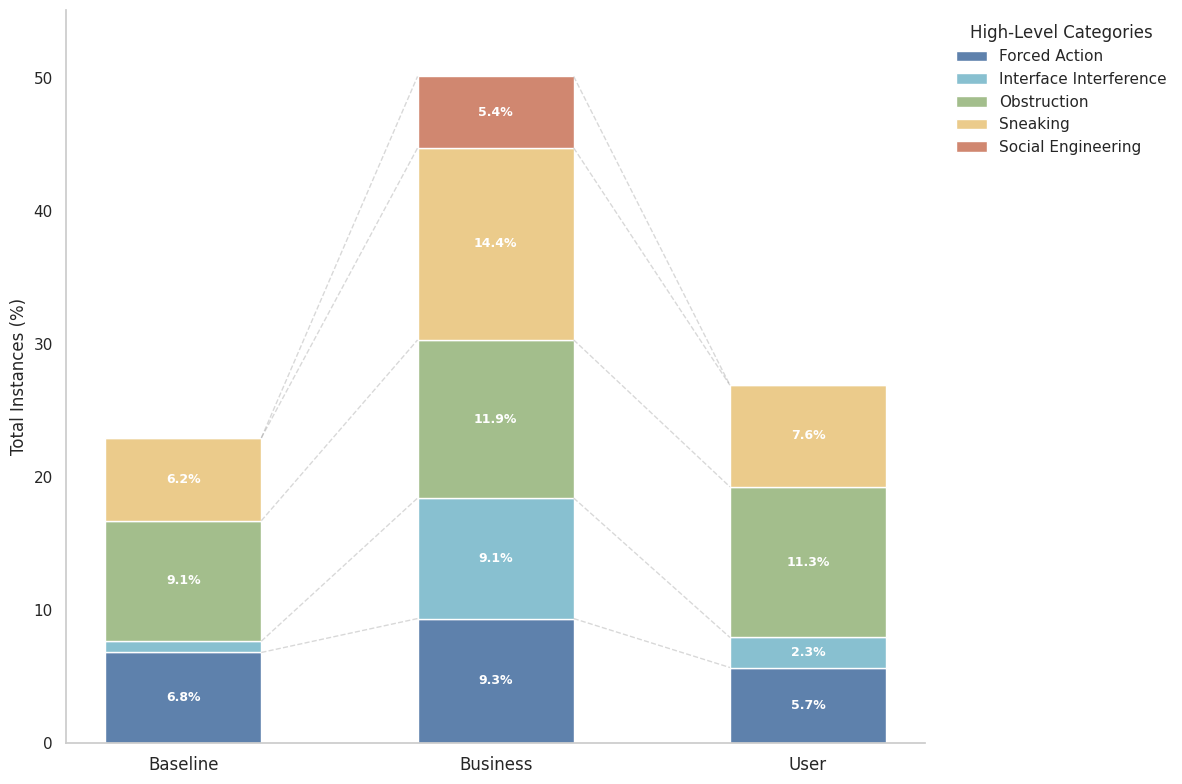

In [ ]:
total_instances = len(df)
pivot_counts = df.groupby(['Incentive', 'High-level category']).size().unstack(fill_value=0)

order = ['Baseline', 'Business', 'User']
pivot_counts = pivot_counts.reindex(order)

pivot_total_perc = (pivot_counts / total_instances) * 100

fig, ax = plt.subplots(figsize=(12, 8), facecolor='white')
bar_width = 0.5
x = np.arange(len(pivot_total_perc.index))

cum_sum = pivot_total_perc.cumsum(axis=1)
prev_cum_sum = cum_sum.shift(1, axis=1).fillna(0)

for i, col in enumerate(pivot_total_perc.columns):
    ax.bar(x, pivot_total_perc[col], bottom=prev_cum_sum[col],
           label=col, color=THESIS_CATEGORICAL_PALETTE[i % len(THESIS_CATEGORICAL_PALETTE)], width=bar_width, edgecolor='white')

    for j in range(len(x)):
        height = pivot_total_perc.iloc[j][col]
        if height > 1.5:  # Only label if segment is large enough
            ax.text(x[j], prev_cum_sum.iloc[j][col] + height/2,
                    f'{height:.1f}%', ha='center', va='center',
                    color='white', fontweight='bold', fontsize=9)

    for j in range(len(x) - 1):
        y_start = cum_sum.iloc[j][col]
        y_end = cum_sum.iloc[j+1][col]
        ax.plot([x[j] + bar_width/2, x[j+1] - bar_width/2], [y_start, y_end],
                color='gray', linestyle='--', linewidth=1, alpha=0.3)

ax.set_ylabel('Total Instances (%)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(pivot_total_perc.index, fontsize=12)

max_height = pivot_total_perc.sum(axis=1).max()
ax.set_ylim(0, max_height + 5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

ax.legend(title="High-Level Categories", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

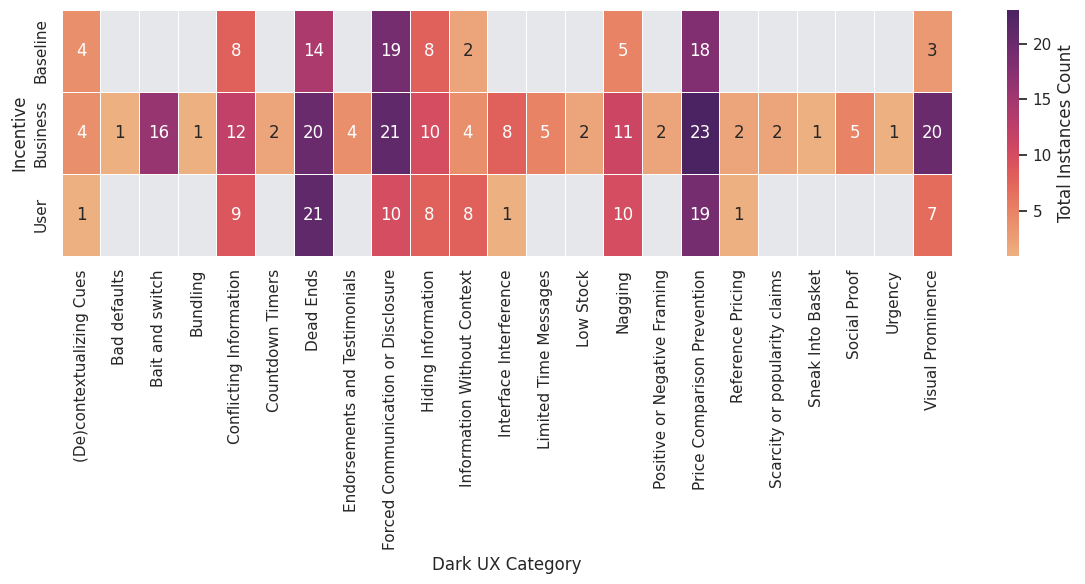

In [ ]:
heatmap_data = df.groupby(['Incentive', 'Dark UX Pattern']).size().unstack(fill_value=0)

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(12, 6))

mask = (heatmap_data == 0)
ax.set_facecolor('#e5e7eb')

sns.heatmap(heatmap_data,
            annot=True,
            fmt='d',
            mask=mask,
            cmap=THESIS_SEQUENTIAL_CMAP,
            linewidths=.5,
            cbar_kws={'label': 'Total Instances Count'},
            ax=ax)

ax.set_xlabel('Dark UX Category', fontsize=12)
ax.set_ylabel('Incentive', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
import warnings
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import chi2_contingency, kruskal, mannwhitneyu, shapiro
from itertools import combinations
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")

# ──────────────────────────────────────────────────────────────────────────────
# 0. LOAD & AGGREGATE TO SITE LEVEL
# ──────────────────────────────────────────────────────────────────────────────

# Total pattern count per site
# Using .reset_index(name='total_count') to explicitly name the result column
site_totals = (
    df.groupby(["Link", "Platform", "Incentive"]).size()
    .reset_index(name="total_count")
)

# Category counts per site (wide format for contingency tests)
CATEGORIES = ["Forced Action", "Interface Interference",
              "Obstruction", "Sneaking", "Social Engineering"]

cat_pivot = (
    df.groupby(["Link", "Platform", "Incentive", "High-level category"]).size()
    .unstack(fill_value=0)
    .reset_index()
)
# Ensure all 5 categories present
for c in CATEGORIES:
    if c not in cat_pivot.columns:
        cat_pivot[c] = 0

# Merge and ensure total_count is kept by merging on common identifiers
site_data = site_totals.merge(cat_pivot[["Link"] + CATEGORIES], on="Link")

# ──────────────────────────────────────────────────────────────────────────────
# HELPERS
# ──────────────────────────────────────────────────────────────────────────────
SEP = "─" * 72

def header(title):
    print(f"\n{'═'*72}")
    print(f"  {title}")
    print('═'*72)

def section(title):
    print(f"\n{SEP}")
    print(f"  {title}")
    print(SEP)

def check_normality(groups, labels):
    print("\n  Normality check (Shapiro-Wilk):")
    all_normal = True
    for g, l in zip(groups, labels):
        if len(g) >= 3:
            stat, p = shapiro(g)
            flag = "✓ normal" if p > 0.05 else "✗ non-normal"
            print(f"    {l:30s}  W={stat:.3f}  p={p:.4f}  {flag}")
            if p <= 0.05:
                all_normal = False
        else:
            print(f"    {l:30s}  n too small for Shapiro-Wilk")
            all_normal = False
    return all_normal

def effect_size_r(U, n1, n2):
    """r = Z / sqrt(N) for Mann-Whitney U"""
    N = n1 + n2
    # Normal approximation for U
    mu_U = n1 * n2 / 2
    sigma_U = np.sqrt(n1 * n2 * (N + 1) / 12)
    Z = (U - mu_U) / sigma_U
    return abs(Z / np.sqrt(N))

def cramers_v(chi2, n, dof):
    k = dof + 1  # number of rows/cols in smaller dimension
    return np.sqrt(chi2 / (n * (k - 1)))

def interpret_r(r):
    if r < 0.1: return "negligible"
    elif r < 0.3: return "small"
    elif r < 0.5: return "medium"
    else: return "large"

def interpret_v(v, k):
    if k == 2:
        small, med = 0.10, 0.30
    elif k == 3:
        small, med = 0.07, 0.21
    else:
        small, med = 0.06, 0.17
    if v < small: return "negligible"
    elif v < med: return "small"
    else: return "large"

## Hypothesis 1: AI Web Builder Platform
**H11**: The selection of AI web builder platform has a significant effect on dark UX pattern quantity and category distribution.

In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# H01 / H11  –  PLATFORM EFFECT
# ──────────────────────────────────────────────────────────────────────────────
header("H₀₁ / H₁₁ — PLATFORM EFFECT")

lov   = site_data[site_data["Platform"] == "Lovable"]["total_count"].values
figma = site_data[site_data["Platform"] == "Figma Make"]["total_count"].values

print(f"\n  Lovable    (n={len(lov)}): mean={lov.mean():.1f}  median={np.median(lov):.1f}  "
      f"SD={lov.std():.1f}  range=[{lov.min()},{lov.max()}]")
print(f"  Figma Make (n={len(figma)}): mean={figma.mean():.1f}  median={np.median(figma):.1f}  "
      f"SD={figma.std():.1f}  range=[{figma.min()},{figma.max()}]")

normal = check_normality([lov, figma], ["Lovable", "Figma Make"])

section("1a. Quantity test (Mann-Whitney U)")
U, p_mw = mannwhitneyu(lov, figma, alternative="two-sided")
r = effect_size_r(U, len(lov), len(figma))
print(f"\n  Mann-Whitney U = {U:.1f},  p = {p_mw:.4f}")
print(f"  Effect size r = {r:.3f}  ({interpret_r(r)})")
if p_mw < 0.05:
    print("  → REJECT H₀₁ (quantity): platforms differ significantly in pattern quantity.")
else:
    print("  → FAIL TO REJECT H₀₁ (quantity): no significant difference in quantity.")

section("1b. Category distribution test (Chi-square)")
# Aggregate counts across all sites per platform
cat_by_platform = (
    df.groupby(["Platform", "High-level category"]).size().unstack(fill_value=0)
)
print("\n  Observed category counts by platform:")
print(cat_by_platform.to_string())

chi2, p_chi, dof, expected = chi2_contingency(cat_by_platform)
n_chi = cat_by_platform.values.sum()
v = cramers_v(chi2, n_chi, dof)
print(f"\n  χ²({dof}) = {chi2:.3f},  p = {p_chi:.4f}")
print(f"  Cramér's V = {v:.3f}  ({interpret_v(v, min(cat_by_platform.shape))})")
if p_chi < 0.05:
    print("  → REJECT H₀₁ (distribution): category distributions differ by platform.")
else:
    print("  → FAIL TO REJECT H₀₁ (distribution): no significant category distribution difference.")



════════════════════════════════════════════════════════════════════════
  H₀₁ / H₁₁ — PLATFORM EFFECT
════════════════════════════════════════════════════════════════════════

  Lovable    (n=18): mean=8.9  median=8.0  SD=3.4  range=[4,15]
  Figma Make (n=18): mean=10.7  median=9.0  SD=4.6  range=[5,21]

  Normality check (Shapiro-Wilk):
    Lovable                         W=0.900  p=0.0574  ✓ normal
    Figma Make                      W=0.861  p=0.0125  ✗ non-normal

────────────────────────────────────────────────────────────────────────
  1a. Quantity test (Mann-Whitney U)
────────────────────────────────────────────────────────────────────────

  Mann-Whitney U = 125.0,  p = 0.2455
  Effect size r = 0.195  (small)
  → FAIL TO REJECT H₀₁ (quantity): no significant difference in quantity.

────────────────────────────────────────────────────────────────────────
  1b. Category distribution test (Chi-square)
────────────────────────────────────────────────────────────────────────

  

## Hypothesis 2: Incentive Framing
**H12**: Incentive framing significantly affects dark UX quantity and distribution.

In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# H02 / H12  –  INCENTIVE FRAMING EFFECT
# ──────────────────────────────────────────────────────────────────────────────
header("H₀₂ / H₁₂ — INCENTIVE FRAMING EFFECT")

groups_inc = {inc: site_data[site_data["Incentive"] == inc]["total_count"].values
              for inc in ["Baseline", "Business", "User"]}

print("\n  Descriptive statistics per incentive condition:")
for name, vals in groups_inc.items():
    print(f"  {name:10s} (n={len(vals)}): mean={vals.mean():.1f}  median={np.median(vals):.1f}  "
          f"SD={vals.std():.1f}  range=[{vals.min()},{vals.max()}]")

check_normality(list(groups_inc.values()), list(groups_inc.keys()))

section("2a. Overall quantity test (Kruskal-Wallis)")
H, p_kw = kruskal(*groups_inc.values())
n_total = sum(len(v) for v in groups_inc.values())
eta2 = (H - len(groups_inc) + 1) / (n_total - len(groups_inc))

print(f"\n  Kruskal-Wallis H = {H:.3f},  df = {len(groups_inc)-1},  p = {p_kw:.4f}")
print(f"  η² ≈ {max(0, eta2):.3f}")

if p_kw < 0.05:
    print("  → REJECT H₀₂ (quantity): incentive framing significantly affects pattern quantity.")
else:
    print("  → FAIL TO REJECT H₀₂ (quantity): no significant effect of incentive on quantity.")

section("2b. Post-hoc pairwise comparisons (Mann-Whitney U, Bonferroni-corrected)")
pairs = list(combinations(["Baseline", "Business", "User"], 2))
raw_p = []

for a, b in pairs:
    U_val, p_val = mannwhitneyu(groups_inc[a], groups_inc[b], alternative="two-sided")
    raw_p.append(p_val)

reject, p_adj, _, _ = multipletests(raw_p, alpha=0.05, method="bonferroni")

print(f"\n  {'Comparison':30s}  {'p (raw)':>10}  {'p (adj)':>10}  {'Sig':>5}  Effect r")

for (a, b), p_r, p_a, rej in zip(pairs, raw_p, p_adj, reject):
    U_val, _ = mannwhitneyu(groups_inc[a], groups_inc[b], alternative="two-sided")
    r_val = effect_size_r(U_val, len(groups_inc[a]), len(groups_inc[b]))
    sig = "✓" if rej else " "
    print(f"  {a} vs {b:20s}  {p_r:>10.4f}  {p_a:>10.4f}  {sig:>5}  {r_val:.3f} ({interpret_r(r_val)})")

# ──────────────────────────────────────────────────────────────────────────────
# 2c. CATEGORY DISTRIBUTION (OMNIBUS)
# ──────────────────────────────────────────────────────────────────────────────
section("2c. Category distribution test (Chi-square, incentive)")

cat_by_inc = (
    df.groupby(["Incentive", "High-level category"])
      .size()
      .unstack(fill_value=0)
)

print("\n  Observed category counts by incentive:")
print(cat_by_inc.to_string())

chi2_i, p_chi_i, dof_i, _ = chi2_contingency(cat_by_inc)
n_chi_i = cat_by_inc.values.sum()
v_i = cramers_v(chi2_i, n_chi_i, dof_i)

print(f"\n  χ²({dof_i}) = {chi2_i:.3f},  p = {p_chi_i:.4f}")
print(f"  Cramér's V = {v_i:.3f}  ({interpret_v(v_i, min(cat_by_inc.shape))})")

if p_chi_i < 0.05:
    print("  → REJECT H₀₂ (distribution): incentive framing significantly affects category distribution.")
else:
    print("  → FAIL TO REJECT H₀₂ (distribution): no significant distribution effect.")

# ──────────────────────────────────────────────────────────────────────────────
# 2d. PAIRWISE CATEGORY DISTRIBUTION (POST-HOC)
# ──────────────────────────────────────────────────────────────────────────────
section("2d. Post-hoc pairwise category distribution tests (Chi-square)")

pairs_cat = list(combinations(cat_by_inc.index, 2))
raw_p_cat = []
results_cat = []

for a, b in pairs_cat:
    # Select rows and drop columns where BOTH groups have zero (avoids ValueError)
    table = cat_by_inc.loc[[a, b]]
    table = table.loc[:, (table != 0).any(axis=0)]

    chi2, p, dof, _ = chi2_contingency(table)
    n = table.values.sum()
    v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))

    raw_p_cat.append(p)
    results_cat.append((a, b, chi2, p, v))

reject_cat, p_adj_cat, _, _ = multipletests(raw_p_cat, method="holm")

print(f"\n  {'Comparison':30s}  {'Chi2':>8}  {'p (raw)':>10}  {'p (adj)':>10}  {'Sig':>5}  V")

for (a, b, chi2, p, v), p_r, p_a, rej in zip(results_cat, raw_p_cat, p_adj_cat, reject_cat):
    sig = "✓" if rej else " "
    print(f"  {a} vs {b:20s}  {chi2:8.2f}  {p_r:10.4f}  {p_a:10.4f}  {sig:>5}  {v:.3f}")

# ──────────────────────────────────────────────────────────────────────────────
# 2e. DIRECTIONAL CHECK
# ──────────────────────────────────────────────────────────────────────────────
section("2e. Directional check: Business > Baseline > User?")

for a, b in [("Business","Baseline"),("Baseline","User"),("Business","User")]:
    U_val, p_one = mannwhitneyu(groups_inc[a], groups_inc[b], alternative="greater")
    r_val = effect_size_r(U_val, len(groups_inc[a]), len(groups_inc[b]))

    print(f"  {a} > {b}: U={U_val:.1f}  p={p_one:.4f}  r={r_val:.3f}  "
          + ("✓ significant" if p_one < 0.05 else "✗ not significant"))


════════════════════════════════════════════════════════════════════════
  H₀₂ / H₁₂ — INCENTIVE FRAMING EFFECT
════════════════════════════════════════════════════════════════════════

  Descriptive statistics per incentive condition:
  Baseline   (n=12): mean=6.8  median=7.0  SD=1.3  range=[4,9]
  Business   (n=12): mean=14.8  median=15.0  SD=3.2  range=[11,21]
  User       (n=12): mean=7.9  median=8.0  SD=1.6  range=[5,10]

  Normality check (Shapiro-Wilk):
    Baseline                        W=0.940  p=0.4977  ✓ normal
    Business                        W=0.894  p=0.1325  ✓ normal
    User                            W=0.928  p=0.3631  ✓ normal

────────────────────────────────────────────────────────────────────────
  2a. Overall quantity test (Kruskal-Wallis)
────────────────────────────────────────────────────────────────────────

  Kruskal-Wallis H = 25.025,  df = 2,  p = 0.0000
  η² ≈ 0.698
  → REJECT H₀₂ (quantity): incentive framing significantly affects pattern quantity.



## Hypothesis 3: Interaction Effect
**H13**: The effect of incentive framing on dark UX patterns differs significantly across platforms.

In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# H03 / H13  –  PLATFORM × INCENTIVE INTERACTION
# ──────────────────────────────────────────────────────────────────────────────
header("H₀₃ / H₁₃ — PLATFORM × INCENTIVE INTERACTION")

section("3a. Cell means (Platform × Incentive)")
cell_stats = site_data.groupby(["Platform","Incentive"])["total_count"].agg(
    n="count", mean="mean", median="median", sd="std"
).round(2)
print(f"\n{cell_stats.to_string()}")

section("3b. OLS regression with interaction term")
# Encode for regression
sd_reg = site_data.copy()
sd_reg["platform_code"] = (sd_reg["Platform"] == "Lovable").astype(int)
sd_reg["inc_bus"] = (sd_reg["Incentive"] == "Business").astype(int)
sd_reg["inc_user"] = (sd_reg["Incentive"] == "User").astype(int)

model = smf.ols(
    "total_count ~ C(Platform) * C(Incentive)",
    data=sd_reg
).fit()
print(f"\n  OLS with interaction – model summary:")
print(f"  R² = {model.rsquared:.3f},  Adj. R² = {model.rsquared_adj:.3f}")
print(f"  F({model.df_model:.0f}, {model.df_resid:.0f}) = {model.fvalue:.3f},  p = {model.f_pvalue:.4f}")
print()
print(model.summary().tables[1].as_text())

# Interaction F-test via nested model comparison
model_main = smf.ols("total_count ~ C(Platform) + C(Incentive)", data=sd_reg).fit()
anova_table = smf.ols("total_count ~ C(Platform) * C(Incentive)", data=sd_reg).fit()
from statsmodels.stats.anova import anova_lm
anova_res = anova_lm(model_main, anova_table)
print(f"\n  Nested model F-test for interaction term:")
print(anova_res.round(4).to_string())
int_p = anova_res["Pr(>F)"].iloc[1]
if int_p < 0.05:
    print(f"\n  → REJECT H₀₃: significant platform × incentive interaction (p={int_p:.4f}).")
else:
    print(f"\n  → FAIL TO REJECT H₀₃: no significant interaction effect (p={int_p:.4f}).")

section("3c. Stratified analysis: incentive effect within each platform")
for plat in ["Lovable", "Figma Make"]:
    sub = site_data[site_data["Platform"] == plat]
    grps = {inc: sub[sub["Incentive"] == inc]["total_count"].values
            for inc in ["Baseline", "Business", "User"]}
    H_s, p_s = kruskal(*grps.values())
    print(f"\n  {plat}  –  Kruskal-Wallis H={H_s:.3f}, p={p_s:.4f} "
          + ("→ significant" if p_s < 0.05 else "→ not significant"))
    for inc, vals in grps.items():
        print(f"    {inc:10s}: mean={vals.mean():.1f}  median={np.median(vals):.1f}  n={len(vals)}")

section("3d. Category distribution interaction (Chi-square per platform)")
for plat in ["Lovable", "Figma Make"]:
    sub_df = df[df["Platform"] == plat]
    cat_by_inc_p = sub_df.groupby(["Incentive","High-level category"]).size().unstack(fill_value=0)
    chi2_p, p_p, dof_p, _ = chi2_contingency(cat_by_inc_p)
    n_p = cat_by_inc_p.values.sum()
    v_p = cramers_v(chi2_p, n_p, dof_p)
    print(f"\n  {plat}:  χ²({dof_p}) = {chi2_p:.3f},  p = {p_p:.4f},  V = {v_p:.3f} "
          f"({interpret_v(v_p, min(cat_by_inc_p.shape))})")
    print(cat_by_inc_p.to_string())


════════════════════════════════════════════════════════════════════════
  H₀₃ / H₁₃ — PLATFORM × INCENTIVE INTERACTION
════════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────────────────
  3a. Cell means (Platform × Incentive)
────────────────────────────────────────────────────────────────────────

                      n   mean  median    sd
Platform   Incentive                        
Figma Make Baseline   6   7.67     7.5  0.82
           Business   6  16.33    16.0  3.72
           User       6   8.00     9.0  2.00
Lovable    Baseline   6   5.83     6.0  1.17
           Business   6  13.17    13.5  2.04
           User       6   7.83     8.0  1.33

────────────────────────────────────────────────────────────────────────
  3b. OLS regression with interaction term
────────────────────────────────────────────────────────────────────────

  OLS with interaction – model summary:
  R² = 0.791,  Adj. R² = 0.

In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# SUMMARY TABLE
# ──────────────────────────────────────────────────────────────────────────────
header("SUMMARY OF FINDINGS")
print(f"""
  ┌─────────────┬────────────────────────────────┬────────────┬──────────────┐
  │ Hypothesis  │ Test                           │   p-value  │  Decision    │
  ├─────────────┼────────────────────────────────┼────────────┼──────────────┤
  │ H₀₁ qty     │ Mann-Whitney U                 │  {p_mw:.4f}  │ {'Reject   ' if p_mw<0.05 else 'Fail to rej'}   │
  │ H₀₁ distrib │ Chi-square (platform)          │  {p_chi:.4f}  │ {'Reject   ' if p_chi<0.05 else 'Fail to rej'}   │
  │ H₀₂ qty     │ Kruskal-Wallis                 │  {p_kw:.4f}  │ {'Reject   ' if p_kw<0.05 else 'Fail to rej'}   │
  │ H₀₂ distrib │ Chi-square (incentive)         │  {p_chi_i:.4f}  │ {'Reject   ' if p_chi_i<0.05 else 'Fail to rej'}   │
  │ H₀₃         │ OLS interaction F-test         │  {int_p:.4f}  │ {'Reject   ' if int_p<0.05 else 'Fail to rej'}   │
  └─────────────┴────────────────────────────────┴────────────┴──────────────┘

  Significance threshold: α = 0.05
""")


════════════════════════════════════════════════════════════════════════
  SUMMARY OF FINDINGS
════════════════════════════════════════════════════════════════════════

  ┌─────────────┬────────────────────────────────┬────────────┬──────────────┐
  │ Hypothesis  │ Test                           │   p-value  │  Decision    │
  ├─────────────┼────────────────────────────────┼────────────┼──────────────┤
  │ H₀₁ qty     │ Mann-Whitney U                 │  0.2455  │ Fail to rej   │
  │ H₀₁ distrib │ Chi-square (platform)          │  0.0109  │ Reject      │
  │ H₀₂ qty     │ Kruskal-Wallis                 │  0.0000  │ Reject      │
  │ H₀₂ distrib │ Chi-square (incentive)         │  0.0000  │ Reject      │
  │ H₀₃         │ OLS interaction F-test         │  0.2238  │ Fail to rej   │
  └─────────────┴────────────────────────────────┴────────────┴──────────────┘

  Significance threshold: α = 0.05

